In [9]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score


# Let's try to load the first 100k rows to check the structure
# and avoid memory errors immediately.
file_name = 'PS_20174392719_1491204439457_log.csv'

try:
    # Reading just a sample first to verify column names and data
    df = pd.read_csv(file_name, nrows=200000)
    print("Sample loaded successfully!")
    print(f"Columns found: {df.columns.tolist()}")
    print(f"\nFraud Distribution in sample:\n{df['isFraud'].value_counts()}")

except FileNotFoundError:
    print(f" Error: The file '{file_name}' was not found. Please check the file name in your Colab sidebar.")
except Exception as e:
    print(f" An unexpected error occurred: {e}")

# If the sample worked, let's load the full relevant subset
# (Filtering by type during read saves massive amounts of RAM)

Sample loaded successfully!
Columns found: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Fraud Distribution in sample:
isFraud
0    199853
1       147
Name: count, dtype: int64


In [11]:
# Create a list to hold the chunks
chunks = []

# Process the file in pieces of 500,000 rows
for chunk in pd.read_csv(file_name, chunksize=500000):
    # Only keep the rows where fraud actually happens
    filtered_chunk = chunk[chunk['type'].isin(['TRANSFER', 'CASH_OUT'])]
    chunks.append(filtered_chunk)

# Combine only the filtered rows into one dataframe
df = pd.concat(chunks, axis=0)

print(f"Full dataset processed!")
print(f"Total rows kept (Transfer/Cash_out only): {len(df):,}")
print(f"Total Fraud cases found: {df['isFraud'].sum()}")

Full dataset processed!
Total rows kept (Transfer/Cash_out only): 2,770,409
Total Fraud cases found: 8213


In [13]:
from sklearn.model_selection import train_test_split

# 1. Create the 'Error' features - the most predictive columns for this dataset
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 2. One-hot encode the type (since we only have TRANSFER and CASH_OUT now)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# 3. Select features and target
# We drop IDs and the target label.
# We keep raw balances + our new error features.
X = df.drop(['isFraud', 'nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)
y = df['isFraud']

# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 2216327
Testing set size: 554082


In [15]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize Random Forest
# class_weight='balanced' is the Random Forest version of scale_pos_weight
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Uses all your CPU cores for faster training
)

print("Training Random Forest... this may take a bit longer than XGBoost...")
start_time = time.time()
rf_model.fit(X_train, y_train)
print(f"RF Training finished in {time.time() - start_time:.2f} seconds.")

# 2. Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. Output Results
print("\n" + "="*40)
print("RANDOM FOREST RESULTS")
print("="*40)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Training Random Forest... this may take a bit longer than XGBoost...
RF Training finished in 64.74 seconds.

RANDOM FOREST RESULTS
ROC-AUC Score: 0.9991

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



In [16]:
from xgboost import XGBClassifier
import time

# Calculate the weight for the 'Fraud' class
# ratio = total_negative / total_positive
ratio = (y == 0).sum() / (y == 1).sum()

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # This handles the imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

print("Starting training... this might take a minute...")
start_time = time.time()
xgb_model.fit(X_train, y_train)
end_time = time.time()

print(f"✓ Training finished in {end_time - start_time:.2f} seconds.")

Starting training... this might take a minute...


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [04:33:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✓ Training finished in 5.90 seconds.



FINAL MODEL RESULTS
ROC-AUC Score: 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.90      0.99      0.94      1643

    accuracy                           1.00    554082
   macro avg       0.95      1.00      0.97    554082
weighted avg       1.00      1.00      1.00    554082



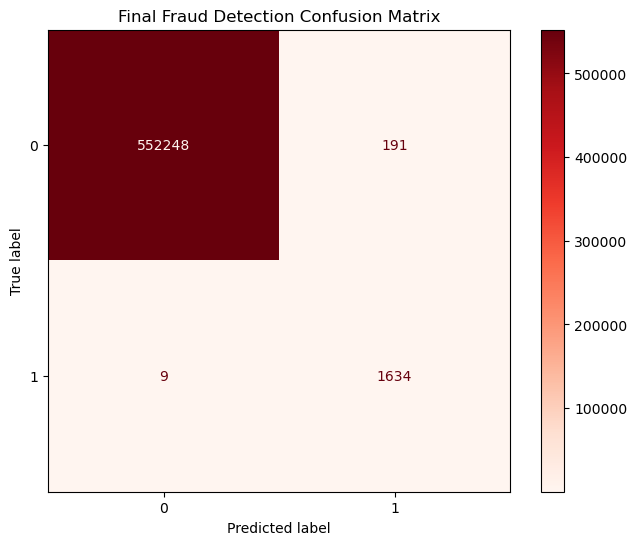

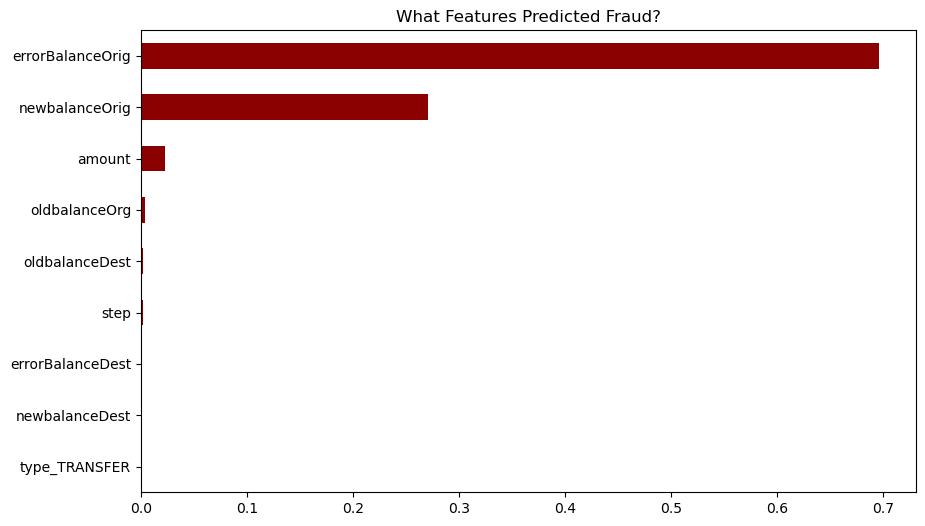

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

# Predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("\n" + "="*40)
print("FINAL MODEL RESULTS")
print("="*40)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Reds', ax=ax)
plt.title('Final Fraud Detection Confusion Matrix')
plt.show()

# Feature Importance - Let's see what the model actually learned
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='darkred')
plt.title('What Features Predicted Fraud?')
plt.show()

In [ ]:
import shap

# Initialize the SHAP explainer
# We use a sample of the test set to speed up calculation
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.iloc[:1000])

# Plot the summary
plt.title("SHAP Feature Importance (How the Model Decides)")
shap.summary_plot(shap_values, X_test.iloc[:1000])

In [ ]:
import shap

# 1. Initialize the Javascript visualization (needed for Force Plots in Colab)
shap.initjs()

# 2. Create the explainer
explainer = shap.TreeExplainer(xgb_model)

# 3. Choose a specific instance (let's pick the first fraud case we find in the test set)
fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]

# 4. Calculate SHAP values for that specific instance
# We use the raw X_test (not scaled) so the numbers make sense in the plot
idx_to_explain = X_test.iloc[sample_idx : sample_idx + 1]
shap_val_single = explainer.shap_values(idx_to_explain)

# 5. Generate the Force Plot
# This shows the 'push' and 'pull' of features for this specific prediction
shap.force_plot(
    explainer.expected_value,
    shap_val_single,
    idx_to_explain,
    matplotlib=True # Set to True to display directly in the notebook
)